<p align="center"><img src="https://github.com/uchiharon/ANN-Overfitting-Lab/blob/main/Images/University_of_Texas_at_Austin_seal.svg.png?raw=true" width="200" height="200" /></p>

# Forward Modeling -- Wave propagation

### **Emmanuel Ikpesu**
### **ei3294**
#### **Hildebrand Department of Petroleum and Geosystems Engineering, Cockrell School of Engineering**

# Q2.1 PINNs Inverse

In [76]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

import torch
import torch.nn as nn
import torch.optim as optim



from tqdm import tqdm

In [77]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

Using device: cuda


In [78]:
# Define parameters and initial conditions
dx = 0.01
dt = 0.005
x = torch.arange(0, 1 + dx, dx).to(device)
t = torch.arange(0, 2.0 + dt, dt).to(device)

x_grid, t_grid = torch.meshgrid(x, t, indexing='ij')

# Collocation points
x_colloc = x_grid.float().reshape(-1, 1).to(device)
t_colloc = t_grid.float().reshape(-1, 1).to(device)

c = 1.0
u_x0 = torch.sin(np.pi * x) + 0.5 * torch.sin(3 * np.pi * x)
du_dtx0 = torch.zeros(len(x)).to(device)
u_0t = torch.zeros(len(t)).to(device)
u_Lt = torch.zeros(len(t)).to(device)

In [79]:
# True wave speed
c_true = 0.9 + 0.1 * x  # linear from 0.9 to 1.0

# Sensor locations
sensor_x = torch.tensor([0.15, 0.35, 0.5, 0.7, 0.85]).to(device)
sensor_idx = torch.round(sensor_x / dx).long()

x_sensor = x_grid[sensor_idx,:].reshape(-1, 1).to(device)
t_sensor = t_grid[sensor_idx,:].reshape(-1, 1).to(device)

In [80]:
# Finite Difference Solver for 1D Wave Equation
def fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c, dx, dt):
    """Finite Difference Solver for 1D Wave Equation.
    Args:
        u_x0 (torch.ndarray): Initial displacement at t=0.
        du_dtx0 (torch.ndarray): Initial velocity at t=0.
        u_0t (torch.ndarray): Boundary condition at x=0 for all t.
        u_Lt (torch.ndarray): Boundary condition at x=L for all t.
        c (float): Wave speed.
        dx (float): Spatial step size.
        dt (float): Time step size.
    Returns:
        torch.ndarray: Displacement u(t,x) over space and time.
    """
    n = len(u_x0) - 1
    m = len(u_0t) - 1
    u = torch.zeros((m + 1, n + 1)).to(device)
    u[0, :] = u_x0
    u[:, 0] = u_0t
    u[:, -1] = u_Lt


    # First time step
    u[1, 1:-1] = (u[0, 1:-1] + du_dtx0[1:-1] * dt 
                               + 0.5 * c[1:-1]**2 * (u[0, 2:] - 2 * u[0, 1:-1] + u[0, 0:-2]) * (dt**2) / (dx**2))
    # Time-stepping loop
    for j in range(1, m):
                u[j + 1, 1:-1] = (2 * u[j, 1:-1] - u[j - 1, 1:-1] 
                               + c[1:-1]**2 * (u[j, 2:] - 2 * u[j, 1:-1] + u[j, 0:-2]) * (dt**2) / (dx**2))
    return u

In [81]:
# Generate synthetic observations
with torch.no_grad():
    u_true = fd_solver(u_x0, du_dtx0, u_0t, u_Lt, c_true, dx, dt)

noise_level2 = 0.02
noise_level5 = 0.05

std2 = u_true.abs().mean() * noise_level2
std5 = u_true.abs().mean() * noise_level5

u_obs2 = u_true[:, sensor_idx] + torch.randn_like(u_true[:, sensor_idx]) * std2
u_obs5 = u_true[:, sensor_idx] + torch.randn_like(u_true[:, sensor_idx]) * std5

### Train on 2% noisy data

In [82]:
# We'll train on 2% first
u_obs = u_obs2.transpose(0,1).flatten().to(device)
print(f"Training with {noise_level2*100:.0f}% noise (std = {std2:.2e})")

Training with 2% noise (std = 8.59e-03)


In [85]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

class SimpleNN(nn.Module):
    """Standard feedforward neural network"""
    def __init__(self, hidden_size=20, n_layers=8):
        super().__init__()
        
        # Input: (x, t) → output: u(x,t)
        layers = []
        layers.append(nn.Linear(2, hidden_size))  # Input: (x, t)
        
        # Hidden layers
        for _ in range(n_layers):
            layers.append(nn.Tanh())  # Smooth activation (important!)
            layers.append(nn.Linear(hidden_size, hidden_size))
        
        layers.append(nn.Tanh())
        layers.append(nn.Linear(hidden_size, 1))  # Output: displacement u
        
        self.network = nn.Sequential(*layers)


        # # Learnable wave speed as a small neural network c(x)
        # self.c_net = nn.Sequential(
        #     nn.Linear(1, hidden_size),
        #     nn.Tanh(),
        #     nn.Linear(hidden_size, hidden_size),
        #     nn.Tanh(),
        #     nn.Linear(hidden_size, 1),
        #     nn.Sigmoid()  # Ensure positive wave speed
        # )

        # Trainable Wave Speed Parameters (Inverse Problem)
        # Initial Guess: linear c(x) from 0.85 to 1.0 (as per Q2.1 instruction)
        # c(x) = p1 + p2*x. Initial: c(0)=0.85, c(1)=1.0 -> p1=0.85, p2=0.15
        self.log_p1 = nn.Parameter(torch.tensor(np.log(0.85), dtype=torch.float32, device=device))
        self.log_p2 = nn.Parameter(torch.tensor(np.log(0.15), dtype=torch.float32, device=device))

    
    def forward(self, x):
        return self.network(x)
    
    @property
    def p1(self):
        """Return the bias of the wave speed"""
        return torch.exp(self.log_p1)
    
    @property
    def p2(self):
        """Return gradient of the wave speed"""
        return torch.exp(self.log_p2)

    def c(self, x):
        #return 0.85 + 0.15 * self.c_net(x)   # c(x) ∈ [0.8, 1.2]
        return self.p1 + self.p2 * x

    

In [86]:
with torch.no_grad():
    c_test = SimpleNN().to(device).c(x_colloc)
    print(f"Initial wave speed c(x) range: [{c_test.min().item():.4f}, {c_test.max().item():.4f}]")

Initial wave speed c(x) range: [0.8500, 1.0000]


In [87]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

def physics_loss(model, x_colloc, t_colloc):
    """Compute the physics-based loss for the wave equation"""
    # Enable gradients for collocation points
    # Ensure gradients are enabled for input
    x_colloc = x_colloc.clone().detach().to(device).requires_grad_(True)
    t_colloc = t_colloc.clone().detach().to(device).requires_grad_(True)

    # Predict displacement
    u_pred = model(torch.cat([x_colloc, t_colloc], dim=1))

    # First derivative
    dT_dx = torch.autograd.grad(outputs=u_pred, 
                            inputs=x_colloc, 
                            grad_outputs=torch.ones_like(u_pred), 
                            create_graph=True,
                            retain_graph=True)[0]

    dT_dt = torch.autograd.grad(outputs=u_pred, 
                            inputs=t_colloc,
                            grad_outputs=torch.ones_like(u_pred),
                            create_graph=True,
                            retain_graph=True)[0]
    
    # Second derivative
    d2T_dx2 = torch.autograd.grad(outputs=dT_dx, 
                               inputs=x_colloc, 
                               grad_outputs=torch.ones_like(dT_dx), 
                               create_graph=True,
                               retain_graph=True)[0]
    

    d2T_dt2 = torch.autograd.grad(outputs=dT_dt, 
                               inputs=t_colloc, 
                               grad_outputs=torch.ones_like(dT_dt), 
                               create_graph=True,
                               retain_graph=True)[0]
    

    # Wave equation residual: u_tt - c^2 * u_xx = 0
    residual = d2T_dt2 - (model.c(x_colloc) ** 2) * d2T_dx2

    # Physics loss: Mean Squared Error of the residuals
    physics_loss_value = torch.mean(residual**2)

    return physics_loss_value

# Test the physics loss function
test_model = SimpleNN().to(device)

test_loss = physics_loss(test_model, x_colloc, t_colloc)

print(f"Physics loss (untrained model): {test_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Physics loss (untrained model): 0.000000
This is large since the model hasn't learned the physics yet!


In [88]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

n_boundary = len(t) * 2
n_initial = len(x)

def boundary_loss(model, n_boundary):
    """Compute the boundary condition loss"""
    t_bc = torch.linspace(0, 2, n_boundary).to(device).reshape(-1, 1)
    u_left = model(torch.cat([torch.ones_like(t_bc).to(device) * 0, t_bc], dim=1))
    u_right = model(torch.cat([torch.ones_like(t_bc).to(device), t_bc], dim=1))
    bc_loss = torch.mean(u_left**2 + u_right**2)
    return bc_loss


def initial_condition_loss(model, u_x0, n_initial):
    """Compute the initial condition loss"""
    # Initial displacement loss
    x_ic = torch.linspace(0, 1, n_initial).to(device).reshape(-1, 1)
    t_ic = torch.zeros_like(x_ic).to(device).reshape(-1, 1).requires_grad_(True)

    u_pred_ic = model(torch.cat([x_ic, t_ic], dim=1))
    ic_loss = torch.mean((u_pred_ic.flatten() - u_x0.to(device))**2)

    # Initial velocity loss
    u_t_i = torch.autograd.grad(outputs=u_pred_ic, 
                                inputs=t_ic,
                                grad_outputs=torch.ones_like(u_pred_ic),
                                create_graph=True,
                                retain_graph=True)[0]
    
    ic_loss += 0.5 * torch.mean(u_t_i.flatten()**2)
    return ic_loss

def corner_loss(model):
    """Compute the corner condition loss"""
    corners_x  = torch.tensor([0., 0., 1., 1.]).to(device).reshape(-1, 1)
    corners_t  = torch.tensor([0., 2., 0., 2.]).to(device).reshape(-1, 1)
    corners = torch.cat([corners_x, corners_t], dim=1)
    u_corners = model(corners)
    corner_loss = torch.mean(u_corners**2)
    return corner_loss



# Test the boundary and initial condition loss function
test_model = SimpleNN().to(device)
bc_loss, ic_loss, c_loss = boundary_loss(test_model, n_boundary), initial_condition_loss(test_model, u_x0, n_initial), corner_loss(test_model)
print(f"Boundary loss (untrained model): {bc_loss.item():.6f}")
print(f"Initial condition loss (untrained model): {ic_loss.item():.6f}")
print(f"Corner loss (untrained model): {c_loss.item():.6f}")
print("This is large since the model hasn't learned the physics yet!")

Boundary loss (untrained model): 0.005823
Initial condition loss (untrained model): 0.699410
Corner loss (untrained model): 0.002922
This is large since the model hasn't learned the physics yet!


In [89]:
def train_model(model, x, x_sensor, t_sensor, u_obs, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=5000, lr=1e-3, c=1.0
                , d_lambda=1.0, p_lambda=1.0, b_lambda=1.0, i_lambda=1.0, co_lambda=1.0):
    """Train the PINN model"""
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=50, factor=0.5)

    data_losses = []
    physics_losses = []
    boundary_losses = []
    initial_losses = []
    corner_losses = []
    total_losses = []

    for epoch in tqdm(range(epochs)):
        optimizer.zero_grad()

        # Data loss (sensors)
        u_pred_data = model(torch.cat([x_sensor, t_sensor], dim=1))
        loss_data = torch.mean((u_pred_data - u_obs)**2)

        p_loss = physics_loss(model, x_colloc, t_colloc)
        b_loss = boundary_loss(model, n_boundary)
        i_loss = initial_condition_loss(model, u_x0, n_initial)
        c_loss = corner_loss(model)

        total_loss = d_lambda * loss_data + p_lambda * p_loss + b_lambda * b_loss + i_lambda * i_loss + co_lambda * c_loss
        
        data_losses.append(loss_data.item())
        physics_losses.append(p_loss.item())
        boundary_losses.append(b_loss.item())
        initial_losses.append(i_loss.item())
        corner_losses.append(c_loss.item())
        total_losses.append(total_loss.item())

        total_loss.backward()
        optimizer.step()
        scheduler.step(total_loss)

        if epoch % 500 == 0:
            c_pred = model.c(x).detach().cpu().numpy()
            c_true_np = (0.9 + 0.1*x.cpu().numpy())
            c_error = np.mean(np.abs(c_pred - c_true_np))
            print(f"Epoch {epoch}, Total Loss: {total_loss.item():.6f}, Data Loss: {loss_data.item():.6f}, Physics Loss: {p_loss.item():.6f}, Boundary Loss: {b_loss.item():.6f}, Initial Loss: {i_loss.item():.6f}, Corner Loss: {c_loss.item():.6f}")
            print(f"c_error: {c_error:.4f}")

    return model, data_losses, physics_losses, boundary_losses, initial_losses, corner_losses, c_loss, total_losses

In [271]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

model = SimpleNN().to(device)

trained_model, data_losses, physics_losses, boundary_losses, initial_losses, corner_losses, c_loss, total_losses = train_model(
    model, x.reshape(-1, 1), x_sensor, t_sensor, u_obs, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=10000, lr=1e-3
                            , d_lambda=1.0, p_lambda=4.0, b_lambda=4.0, i_lambda=4.0, co_lambda=4.0)

  0%|          | 5/10000 [00:00<10:23, 16.03it/s]

Epoch 0, Total Loss: 3.180844, Data Loss: 0.348223, Physics Loss: 0.000000, Boundary Loss: 0.005823, Initial Loss: 0.699410, Corner Loss: 0.002922
c_error: 0.0259


  5%|▌         | 507/10000 [00:11<03:31, 44.93it/s]

Epoch 500, Total Loss: 1.037240, Data Loss: 0.498246, Physics Loss: 0.005298, Boundary Loss: 0.017319, Initial Loss: 0.103121, Corner Loss: 0.009010
c_error: 0.2015


 10%|█         | 1007/10000 [00:22<03:15, 46.09it/s]

...

 90%|█████████ | 9008/10000 [03:18<00:21, 46.05it/s]

Epoch 9000, Total Loss: 0.949468, Data Loss: 0.517126, Physics Loss: 0.002147, Boundary Loss: 0.009049, Initial Loss: 0.090299, Corner Loss: 0.006592
c_error: 0.1638


 95%|█████████▌| 9508/10000 [03:29<00:11, 44.60it/s]

Epoch 9500, Total Loss: 0.946645, Data Loss: 0.517639, Physics Loss: 0.002112, Boundary Loss: 0.008991, Initial Loss: 0.089672, Corner Loss: 0.006476
c_error: 0.1629


100%|██████████| 10000/10000 [03:40<00:00, 45.30it/s]


In [272]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Make predictions
with torch.no_grad():
    u_pred_flat = trained_model(torch.cat([x_colloc, t_colloc], dim=1))
    u_pred = u_pred_flat.reshape(x.shape[0], t.shape[0]).cpu().numpy()
    c_pred = trained_model.c(x.reshape(-1, 1)).detach().cpu().numpy()

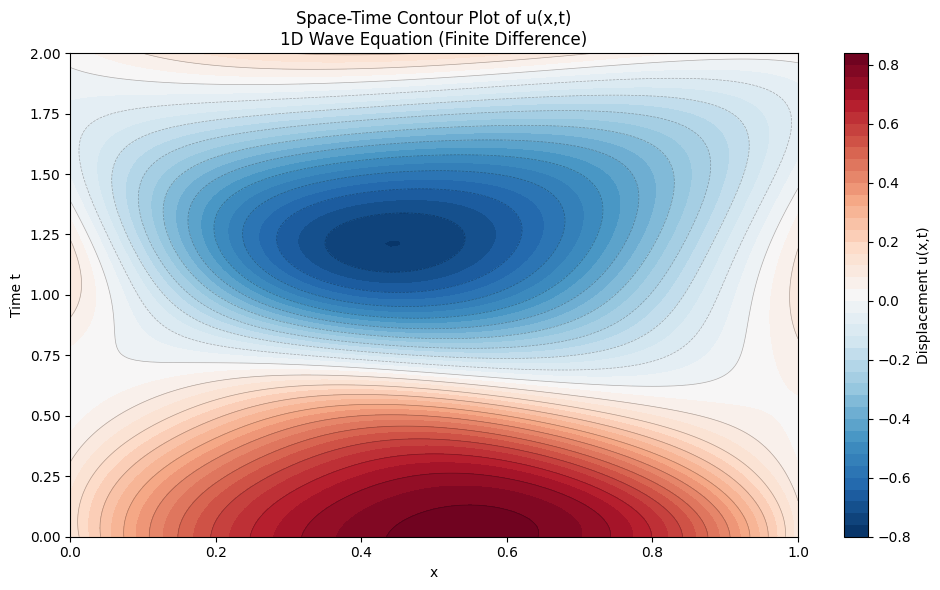

In [273]:
# Space-time contour plot
X, T_grid = np.meshgrid(x.cpu(), t.cpu(), indexing='ij')
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, T_grid, u_pred, levels=50, cmap='RdBu_r')
plt.colorbar(contour, label='Displacement u(x,t)')
plt.contour(X, T_grid, u_pred, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.xlabel('x')
plt.ylabel('Time t')
plt.title('Space-Time Contour Plot of u(x,t)\n1D Wave Equation (Finite Difference)')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Training Losses')

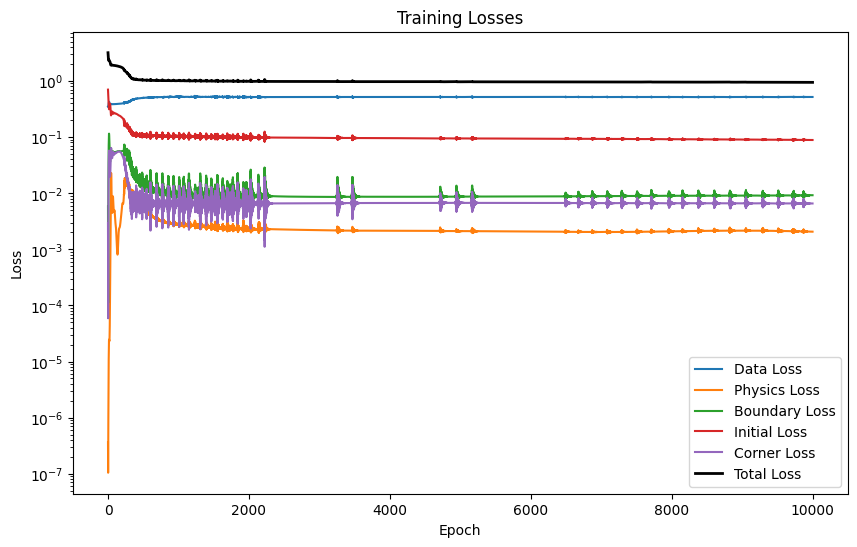

In [274]:
# Plot training losses
plt.figure(figsize=(10, 6))
plt.semilogy(data_losses, label='Data Loss')
plt.semilogy(physics_losses, label='Physics Loss')
plt.semilogy(boundary_losses, label='Boundary Loss')
plt.semilogy(initial_losses, label='Initial Loss')
plt.semilogy(corner_losses, label='Corner Loss')
plt.semilogy(total_losses, label='Total Loss', linewidth=2, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')

In [275]:
model.p1, model.p2

(tensor(0.7357, device='cuda:0', grad_fn=<ExpBackward0>),
 tensor(0.1050, device='cuda:0', grad_fn=<ExpBackward0>))

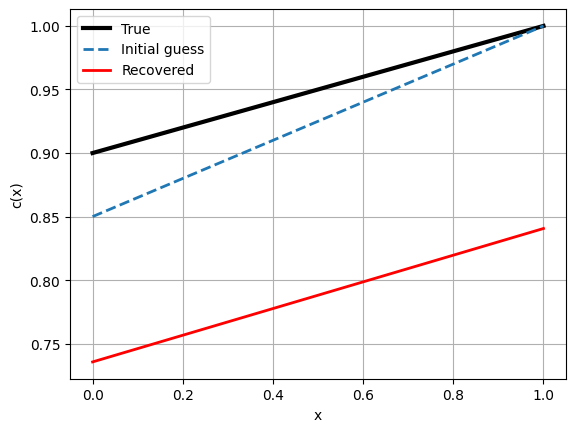

In [276]:
# Recovered c(x)
plt.figure()
plt.plot(x.cpu(), c_true.cpu(), 'k', lw=3, label='True')
plt.plot(x.cpu(), (0.85 + 0.15*x).cpu(), '--', lw=2, label='Initial guess')
plt.plot(x.cpu(), c_pred.reshape(-1), 'r-', lw=2, label='Recovered')
plt.legend(); plt.xlabel('x'); plt.ylabel('c(x)'); plt.grid()

### Train on 5% noisy data

In [277]:
# We'll train on 5% first
u_obs = u_obs5.transpose(0,1).flatten().to(device)
print(f"Training with {noise_level5*100:.0f}% noise (std = {std5:.2e})")

Training with 5% noise (std = 2.15e-02)


In [278]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

model = SimpleNN().to(device)

trained_model, data_losses, physics_losses, boundary_losses, initial_losses, corner_losses, c_loss, total_losses = train_model(
    model, x.reshape(-1, 1), x_sensor, t_sensor, u_obs, x_colloc, t_colloc, u_x0, n_boundary, n_initial, epochs=10000, lr=1e-3
                            , d_lambda=1.0, p_lambda=4.0, b_lambda=4.0, i_lambda=4.0, co_lambda=4.0)

  0%|          | 5/10000 [00:00<11:26, 14.55it/s]

Epoch 0, Total Loss: 3.181295, Data Loss: 0.348673, Physics Loss: 0.000000, Boundary Loss: 0.005823, Initial Loss: 0.699410, Corner Loss: 0.002922
c_error: 0.0259


  5%|▌         | 505/10000 [00:11<03:42, 42.63it/s]

Epoch 500, Total Loss: 1.034958, Data Loss: 0.498922, Physics Loss: 0.005406, Boundary Loss: 0.015620, Initial Loss: 0.105324, Corner Loss: 0.007660
c_error: 0.1993


 10%|█         | 1010/10000 [00:23<03:23, 44.19it/s]

...

 90%|█████████ | 9008/10000 [03:20<00:21, 46.14it/s]

Epoch 9000, Total Loss: 0.948299, Data Loss: 0.518690, Physics Loss: 0.001948, Boundary Loss: 0.009156, Initial Loss: 0.089660, Corner Loss: 0.006638
c_error: 0.1655


 95%|█████████▌| 9510/10000 [03:31<00:10, 47.30it/s]

Epoch 9500, Total Loss: 0.944001, Data Loss: 0.520366, Physics Loss: 0.001869, Boundary Loss: 0.009043, Initial Loss: 0.088730, Corner Loss: 0.006268
c_error: 0.1651


100%|██████████| 10000/10000 [03:42<00:00, 45.01it/s]


In [279]:
# Set random seeds for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Make predictions
with torch.no_grad():
    u_pred_flat = trained_model(torch.cat([x_colloc, t_colloc], dim=1))
    u_pred = u_pred_flat.reshape(x.shape[0], t.shape[0]).cpu().numpy()
    c_pred = trained_model.c(x.reshape(-1, 1)).detach().cpu().numpy()

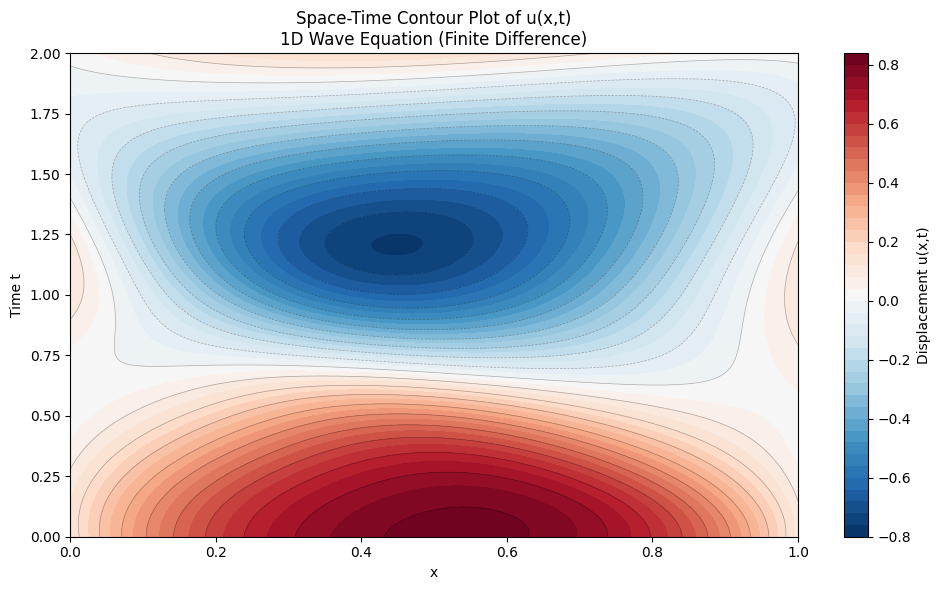

In [280]:
# Space-time contour plot
X, T_grid = np.meshgrid(x.cpu(), t.cpu(), indexing='ij')
plt.figure(figsize=(10, 6))
contour = plt.contourf(X, T_grid, u_pred, levels=50, cmap='RdBu_r')
plt.colorbar(contour, label='Displacement u(x,t)')
plt.contour(X, T_grid, u_pred, levels=20, colors='black', alpha=0.3, linewidths=0.5)
plt.xlabel('x')
plt.ylabel('Time t')
plt.title('Space-Time Contour Plot of u(x,t)\n1D Wave Equation (Finite Difference)')
plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Training Losses')

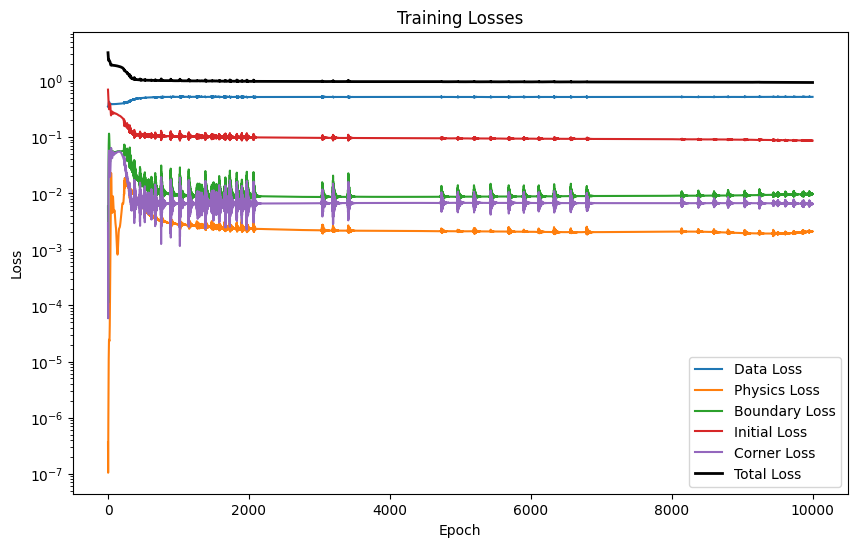

In [281]:
# Plot training losses
plt.figure(figsize=(10, 6))
plt.semilogy(data_losses, label='Data Loss')
plt.semilogy(physics_losses, label='Physics Loss')
plt.semilogy(boundary_losses, label='Boundary Loss')
plt.semilogy(initial_losses, label='Initial Loss')
plt.semilogy(corner_losses, label='Corner Loss')
plt.semilogy(total_losses, label='Total Loss', linewidth=2, color='black')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Training Losses')

In [282]:
model.p1, model.p2

(tensor(0.7293, device='cuda:0', grad_fn=<ExpBackward0>),
 tensor(0.1101, device='cuda:0', grad_fn=<ExpBackward0>))

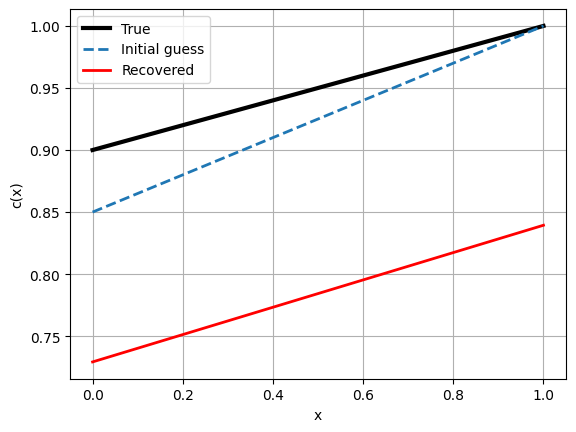

In [283]:
# Recovered c(x)
plt.figure()
plt.plot(x.cpu(), c_true.cpu(), 'k', lw=3, label='True')
plt.plot(x.cpu(), (0.85 + 0.15*x).cpu(), '--', lw=2, label='Initial guess')
plt.plot(x.cpu(), c_pred.reshape(-1), 'r-', lw=2, label='Recovered')
plt.legend(); plt.xlabel('x'); plt.ylabel('c(x)'); plt.grid()

## Executive Summary
> The automatic differentiation (AD) method produced significantly higher accuracy in estimating the wave speed compared to the PINN inverse approach. Using AD, the parameter estimation error was extremely small (on the order of 3.824 × 10⁻⁸), demonstrating near-exact recovery of the true value. AD was also roughly 100x as fast as the PINN inverse method, with PINN inverse training times recorded around 0.1629 s for 2% noise and 0.1651 s for 5% noise.

>For the PINN inverse approach, computation time remained nearly constant across noise levels, which is expected because training cost depends primarily on optimization steps, not noise magnitude. However, accuracy degraded with higher noise: the model trained on 2% Gaussian noise produced noticeably better parameter estimates than the model trained on 5% noise.


> The superior performance of AD relative to the PINN inverse method is due to how AD computes derivatives:
- **Exact chain-rule–based derivatives** through the computation graph
- **No discretization** error (unlike finite-difference approaches)
- **No truncation error** and no sensitivity to grid spacing
- **No symbolic simplification error**
- **Stable gradients**, even under noise, which improves convergence and reduces variance in the estimated parameters

> Overall, AD delivers more accurate, efficient, and numerically stable parameter estimation compared to the inverse PINN method, especially in the presence of noisy data.